<figure>
  <img src="https://raw.githubusercontent.com/shadowkshs/DimABSA2026/refs/heads/main/banner.png" width="100%">
</figure>

# SemEval-2026 Task 3 (Track A: DimABSA, Track B: DimStance)
# Subtask 1: Dimensional Aspect Sentiment Regression (DimASR)

-----

## Starter Notebook
Leveraging Pretrained Language Models for Dimensional Sentiment Regression


## Introduction:

You are welcome to participate in our SemEval Shared Task!

In this starter notebook, we will take you through the process of fine-tuning a pre-trained language model on a sample data to build a sentiment regressor. The notebook was adapted from a Hugginface implementation for such tasks.

### Outline:

- Installation and importation of necessary libraries
Setting up the project parameters.
Running training and evaluation
Before you start:

- It is strongly advised that you use a GPU to speed up training. To do this, go to the "Runtime" menu in Colab, select "Change runtime type" and then in the popup menu, choose "GPU" in the "Hardware accelerator" box.

### NB:

The codes in this notebook are provided to familiarize yourselves with fine-tuning language models for sentiment regression. You may extend and (or) modify as appropriate to obtain competitive performances.

### Languages and Domains:
#### Track A: Subtask 1
- eng_restaurant
- eng_laptop
- jpn_hotel
- jpn_finance
- rus_restaurant
- tat_restaurant
- ukr_restaurant
- zho_restaurant
- zho_laptop
#### Track B: Subtask 1
- deu-stance
- eng-stance
- hau-stance
- kin-stance
- swa-stance
- twi-stance


### Model:
This Starter Notebook uses the bert-base-multilingual-cased pretrained model, developed by Google. The model was trained with a masked language modeling (MLM) objective on the top 104 languages with the largest Wikipedia presence. You can find the model here: https://huggingface.co/google-bert/bert-base-multilingual-cased

If your target language is not included in the common set supported by this model, you can search for a more suitable model on Hugging Face: https://huggingface.co/models



In [1]:
import json
from typing import List, Dict
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel

from scipy.stats import pearsonr
from tqdm import tqdm
import math
import re
import requests

def load_jsonl_url(url):
    """
    Fetches and parses a JSONL file (one JSON object per line) from a URL.
    """
    try:
        response = requests.get(url)
        response.raise_for_status()
        data = [json.loads(line) for line in response.text.strip().split('\n') if line]
        return data
    except Exception as e:
        print(f"Error loading JSONL from {url}: {e}")
        return None

def load_json_url(url):
    """
    Fetches and parses a single, complete JSON file from a URL.
    """
    try:
        response = requests.get(url)
        response.raise_for_status()
        data = response.json() # Use .json() for a single JSON object/list
        return data
    except Exception as e:
        print(f"Error loading JSON from {url}: {e}")
        return None

def transform_sighan_data(external_data, language="zho", domain="restaurant"):
    """
    Transforms the SIGHAN 2024 data structure (a list) into the
    "Quadruplet" format your code expects.
    """
    print(f"Transforming SIGHAN data...")
    transformed_data = []

    for entry in external_data:
        quadruplet_list = []

        # Loop through the parallel lists in the SIGHAN data
        for i in range(len(entry["Aspect"])):
            quad = {
                "Aspect": entry["Aspect"][i],
                "Category": entry["Category"][i],
                "Opinion": entry["Opinion"][i],
                "VA": entry["Intensity"][i] # Already in "V#A" format
            }
            quadruplet_list.append(quad)

        # Build the final dictionary in the target format
        new_entry = {
            "ID": entry["ID"],
            "Text": entry["Sentence"], # Map "Sentence" to "Text"
            "language": language,
            "domain": domain,
            "Quadruplet": quadruplet_list # This is the key your code expects
        }
        transformed_data.append(new_entry)

    print(f"Successfully transformed {len(transformed_data)} new sentences.")
    return transformed_data

### First, visit the [DimABSA2006](https://github.com/DimABSA/DimABSA2026) repository, check the task-dataset.

### Step 1: Load the competition data

- Read JSONL files (train/dev/predict) into Colab.  
- Train files contain Valence–Arousal (VA) labels.  
- Predict files have no VA labels.  
- This script:
  1. Loads the JSONL data.
  2. Splits 10% of train data as dev set.
  3. Converts JSONL into DataFrames (ID, Text, Aspect, Valence, Arousal).
  4. Prints the first few rows for checking.


In [2]:
# --- Config ---
subtask = "subtask_1"
task = "task1"
langs = ["eng", "zho"]
domains = ["restaurant", "laptop","finance","hotel"]

all_train = []
all_dev = []

# --- 1. Load DimABSA 2026 Data (JSONL) ---
print("--- Loading DimABSA 2026 Data ---")
for lang in langs:
    for domain in domains:

        if domain=="finance":
            specified_task = "task1"
        else:
            specified_task = "alltasks"
        # specified_task = "alltasks"
        
        train_url = f"https://raw.githubusercontent.com/DimABSA/DimABSA2026/refs/heads/main/task-dataset/track_a/{subtask}/{lang}/{lang}_{domain}_train_{specified_task}.jsonl"
        dev_url = f"https://raw.githubusercontent.com/DimABSA/DimABSA2026/refs/heads/main/task-dataset/track_a/{subtask}/{lang}/{lang}_{domain}_dev_{task}.jsonl"

        try:
            train_raw = load_jsonl_url(train_url) # Use JSONL loader
            if train_raw:
                for r in train_raw:
                    r["language"] = lang
                    r["domain"] = domain
                all_train.extend(train_raw)
                print(f"Loaded DimABSA Train: {lang}-{domain} ✅")

            dev_raw = load_jsonl_url(dev_url) # Use JSONL loader
            if dev_raw:
                for r in dev_raw:
                    r["language"] = lang
                    r["domain"] = domain
                all_dev.extend(dev_raw)
                print(f"Loaded DimABSA Dev: {lang}-{domain} ✅")

        except Exception as e:
            print(f"Skipped {lang}-{domain}: {e}")





# --- 2. Load augmented DimABSA 2026 Data (JSONL) ---
print("--- Loading augmented DimABSA 2026 Data ---")
for lang in langs:
    for domain in domains:
        train_url = f"https://raw.githubusercontent.com/affan002/DimABSA-SemEval-task03/refs/heads/main/augmented_datasets/first_aug_synthetic_llama_8b/augmented_{lang}_{domain}_train_alltasks.jsonl"

        try:
            train_raw = load_jsonl_url(train_url) # Use JSONL loader
            if train_raw:
              for r in train_raw:
                r["language"]= lang
                r["domain"] = domain
              all_train.extend(train_raw)
              print(f"Loaded DimABSA Train: {lang}-{domain} ✅")

        except Exception as e:
            print(f"Skipped {lang}-{domain}: {e}")


# --- 2. Load External SIGHAN 2024 Data (JSON) ---
print("\n--- Loading External SIGHAN 2024 Data ---")
sighan_urls = {
    "SIGHAN_Train1": "https://raw.githubusercontent.com/NYCU-NLP/SIGHAN2024-dimABSA/refs/heads/main/DataSets/dimABSA2024/Simplified/SIGHAN2024_dimABSA_TrainingSet1_Simplified.json",
    "SIGHAN_Train2": "https://raw.githubusercontent.com/NYCU-NLP/SIGHAN2024-dimABSA/refs/heads/main/DataSets/dimABSA2024/Simplified/SIGHAN2024_dimABSA_TrainingSet2_Simplified.json"
}

for name, url in sighan_urls.items():
    try:
        print(f"Fetching and processing {name}...")

        # 1. Fetch the raw data (it's a JSON file)
        external_raw_data = load_json_url(url) # Use NEW JSON loader

        if external_raw_data:
            # 2. Transform the raw data directly in memory
            external_transformed_data = transform_sighan_data(
                external_data=external_raw_data,
                language="zho",
                domain="restaurant" # SIGHAN data is restaurant domain
            )

            # 3. Add the new data to the main training list
            all_train.extend(external_transformed_data)
            print(f"Successfully added {len(external_transformed_data)} items from {name}.")

    except Exception as e:
        print(f"Failed to load or transform external data from {name}: {e}")

# --- Summary ---
print("\n--- Data Loading Complete ---")
print(f"Total training samples: {len(all_train)}")
print(f"Total dev (prediction) samples: {len(all_dev)}")


#model config
model_name = "xlm-roberta-base" # chage your transformer model
lr = 2e-5 #learning rate

--- Loading DimABSA 2026 Data ---
Loaded DimABSA Train: eng-restaurant ✅
Loaded DimABSA Dev: eng-restaurant ✅
Loaded DimABSA Train: eng-laptop ✅
Loaded DimABSA Dev: eng-laptop ✅
Error loading JSONL from https://raw.githubusercontent.com/DimABSA/DimABSA2026/refs/heads/main/task-dataset/track_a/subtask_1/eng/eng_finance_train_task1.jsonl: 404 Client Error: Not Found for url: https://raw.githubusercontent.com/DimABSA/DimABSA2026/refs/heads/main/task-dataset/track_a/subtask_1/eng/eng_finance_train_task1.jsonl
Error loading JSONL from https://raw.githubusercontent.com/DimABSA/DimABSA2026/refs/heads/main/task-dataset/track_a/subtask_1/eng/eng_finance_dev_task1.jsonl: 404 Client Error: Not Found for url: https://raw.githubusercontent.com/DimABSA/DimABSA2026/refs/heads/main/task-dataset/track_a/subtask_1/eng/eng_finance_dev_task1.jsonl
Error loading JSONL from https://raw.githubusercontent.com/DimABSA/DimABSA2026/refs/heads/main/task-dataset/track_a/subtask_1/eng/eng_hotel_train_alltasks.jsonl

another transformer models you can try:
1. roberta-large
2. roberta-base
3. bert-base-uncased

more models please visit [huggingface](https://huggingface.co/models)

In [3]:
def normalize_list_keys(data_list):
    """
    Standardizes a list of dicts so EVERY entry has a 'Quadruplet' key.
    Correctly handles Task 1 input (list of Aspect strings).
    """
    normalized = []
    for entry in data_list:
        # Create a copy to avoid modifying the original list in place
        new_entry = entry.copy()
        
        # 1. Find the data
        items = []
        if 'Quadruplet' in new_entry:
            items = new_entry.pop('Quadruplet')
        elif 'Triplet' in new_entry:
            items = new_entry.pop('Triplet')
        elif 'Aspect_VA' in new_entry:
            items = new_entry.pop('Aspect_VA')
        elif 'Aspect' in new_entry:
            aspect_data = new_entry.pop('Aspect')
            # --- FIX: Handle list of strings (Task 1 Input) ---
            if isinstance(aspect_data, list):
                # Transform ["food", "service"] -> [{"Aspect": "food"}, {"Aspect": "service"}]
                items = [{'Aspect': a, 'VA': '5.0#5.0'} for a in aspect_data]
            else:
                # Handle single string case
                items = [{'Aspect': aspect_data, 'VA': '5.0#5.0'}]
        
        # 2. Standardize the list items
        # We ensure every item has all 4 keys, filling missing ones with NULL
        safe_items = []
        if isinstance(items, list):
            for item in items:
                # Handle case where item might be a string (rare edge case)
                if isinstance(item, str):
                    item = {'Aspect': item}
                    
                safe_items.append({
                    "Aspect": item.get("Aspect", "NULL"),
                    "Category": item.get("Category", "NULL"),
                    "Opinion": item.get("Opinion", "NULL"),
                    "VA": item.get("VA", "5.0#5.0") # Default VA prevents KeyError
                })
        
        # 3. Set the standard key
        new_entry['Quadruplet'] = safe_items
        normalized.append(new_entry)
        
    return normalized

# --- RERUN NORMALIZATION ---
print("Re-normalizing data keys...")
all_train_normalized = normalize_list_keys(all_train)
all_dev_normalized = normalize_list_keys(all_dev)
print("✅ Data normalized. Now you can run jsonl_to_df.")

Re-normalizing data keys...
✅ Data normalized. Now you can run jsonl_to_df.


In [4]:
#==== step 1 load the data ====
# you can change the env for your task.
# train data should have the VA labels, predit data without VA labels

def jsonl_to_df(data):
    if 'Quadruplet' in data[0]:
        df = pd.json_normalize(data, 'Quadruplet', ['ID', 'Text', 'language', 'domain'])
        df[['Valence', 'Arousal']] = df['VA'].str.split('#', expand=True).astype(float)
        df = df.drop(columns=['VA', 'Category', 'Opinion'])  # drop unnecessary columns
        df = df.drop_duplicates(subset=['ID', 'Aspect'], keep='first')  # remove duplicate ID+Aspect

    elif 'Triplet' in data[0]:
        df = pd.json_normalize(data, 'Triplet', ['ID', 'Text', 'language', 'domain'])
        df[['Valence', 'Arousal']] = df['VA'].str.split('#', expand=True).astype(float)
        df = df.drop(columns=['VA', 'Opinion'])  # drop unnecessary columns
        df = df.drop_duplicates(subset=['ID', 'Aspect'], keep='first')  # remove duplicate ID+Aspect

    elif 'Aspect' in data[0]:
        df = pd.json_normalize(data, 'Aspect', ['ID', 'Text', 'language', 'domain'])
        df = df.rename(columns={df.columns[0]: "Aspect"})  # rename to Aspect
        df['Valence'] = 0  # default value
        df['Arousal'] = 0  # default value
   
    elif 'Aspect_VA' in data[0]:
        df = pd.json_normalize(data, 'Aspect_VA', ['ID', 'Text', 'language', 'domain'])
        df[['Valence', 'Arousal']] = df['VA'].str.split('#', expand=True).astype(float)
        df = df.drop(columns=['VA'])  # drop unnecessary columns
        df = df.drop_duplicates(subset=['ID', 'Aspect'], keep='first')  # remove duplicate ID+Aspect
    else:
        raise ValueError("Invalid format: must include 'Quadruplet' or 'Triplet' or 'Aspect'")

    return df


# --- 3. Create DataFrames ---
train_df = jsonl_to_df(all_train_normalized)
predict_df = jsonl_to_df(all_dev_normalized)

# --- 4. Create STRATIFIED Validation Split ---
print("Creating stratified validation split...")

# We create a 'stratify_key' by combining language and domain
train_df['stratify_key'] = train_df['language'] + '_' + train_df['domain']

final_train_df, final_dev_df = train_test_split(
    train_df,
    test_size=0.1, # or 0.2
    random_state=42,
    # This is the magic fix:
    stratify=train_df['stratify_key']
)

# We don't need the key anymore
final_train_df = final_train_df.drop(columns=['stratify_key'])
final_dev_df = final_dev_df.drop(columns=['stratify_key'])

print("Split complete.")
print(f"Total training samples: {len(final_train_df)}")
print(f"Total validation samples: {len(final_dev_df)}")

Creating stratified validation split...
Split complete.
Total training samples: 34316
Total validation samples: 3813


### Display the dataframe

In [5]:
from IPython.display import display, Markdown

display(Markdown(f"### {subtask}_{lang}_{domain} final_train_df"))
display(final_train_df.head())

display(Markdown(f"### {subtask}_{lang}_{domain} final_dev_df"))
display(final_dev_df.head())

display(Markdown(f"### {subtask}_{lang}_{domain} predict_df"))
display(predict_df.head())

### subtask_1_zho_hotel final_train_df

,Aspect,ID,Text,language,domain,Valence,Arousal
23447,LegionPro7i的外觀,7069536:S012,LegionPro7i的外觀跟色彩我很喜歡,zho,laptop,6.67,5.50
30476,NULL,eng_laptop_quad_train_augmented_628,"Bought the NULL for my grandson's college, and...",eng,laptop,7.75,7.38
27948,NULL,eng_rest16_quad_dev_augmented_643,The food is way overrated at this restaurant!,eng,restaurant,3.12,5.75
44307,用餐体验,R3078:S005,在地特产搭配师傅的巧手打造出极致的用餐体验。,zho,restaurant,7.25,7.50
19196,hp筆電,7074261:S001,"1.79kg這台hp筆電比較重買這兩台不如買微星這台速度快一些,價格又便宜。MSI微星15....",zho,laptop,4.00,5.17


### subtask_1_zho_hotel final_dev_df

,Aspect,ID,Text,language,domain,Valence,Arousal
40558,饭,R1177:S022,饭更是甜美无比。,zho,restaurant,6.12,5.88
2659,food,rest16_quad_train_899,the food was actually aweful .,eng,restaurant,1.33,8.17
27296,portions,eng_rest16_quad_dev_augmented_174,The portions were not the biggest but still ad...,eng,restaurant,4.67,4.50
14073,牛肉,R2844:S003,牛肉堡牛肉多汁好吃。,zho,restaurant,5.83,5.50
36805,NB,zho_laptop_quad_train_augmented_2204,"很不錯的NB~也很不錯的MD,性能真的不錯。",zho,laptop,6.00,4.17


### subtask_1_zho_hotel predict_df

,Aspect,ID,Text,language,domain,Valence,Arousal
0,diner food,rest26_aspect_va_dev_1,Great diner food and breakfast is served all day,eng,restaurant,5.0,5.0
1,breakfast,rest26_aspect_va_dev_1,Great diner food and breakfast is served all day,eng,restaurant,5.0,5.0
2,food,rest26_aspect_va_dev_2,It got very crowded but we still received exce...,eng,restaurant,5.0,5.0
3,drinks,rest26_aspect_va_dev_2,It got very crowded but we still received exce...,eng,restaurant,5.0,5.0
4,service,rest26_aspect_va_dev_2,It got very crowded but we still received exce...,eng,restaurant,5.0,5.0


### Step 2: Build Dataset and DataLoader

- Define a custom `VADataset` class for PyTorch:
  - Joins Aspect + Text into a single input string.
  - Uses BERT tokenizer to create `input_ids` and `attention_mask`.
  - Returns `[Valence, Arousal]` labels as float tensor.
- Convert the processed DataFrames into PyTorch `Dataset` objects.
- Wrap them with `DataLoader` for mini-batch training and evaluation.

In [6]:

MAX_LEN = 128

BATCH_SIZE = 32

#==== Dataset ====
class VADataset(Dataset):
    '''
    A PyTorch Dataset for Valence–Arousal regression with language + domain context.

    - Combines language, domain, aspect, and text into a single input:
        e.g., "[ENG] [LAPTOP] keyboard: The keyboard is good"
    - Tokenizes the input using a HuggingFace tokenizer.
    - Returns:
        * input_ids: token IDs, shape [max_len]
        * attention_mask: mask, shape [max_len]
        * labels: [Valence, Arousal], shape [2], float tensor

    Args:
        dataframe (pd.DataFrame): must contain columns
            "Text", "Aspect", "Valence", "Arousal", "language", "domain".
        tokenizer: HuggingFace tokenizer.
        max_len (int): max sequence length.
    '''
    def __init__(self, dataframe, tokenizer, max_len=128):
        self.sentences = dataframe["Text"].tolist()
        self.aspects = dataframe["Aspect"].tolist()
        self.labels = dataframe[["Valence", "Arousal"]].values.astype(float)
        # self.languages = dataframe["language"].tolist()
        # self.domains = dataframe["domain"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        # lang = self.languages[idx].upper()
        # domain = self.domains[idx].upper() # The model is already multilingual, adding [LANG]
        text = f"{self.aspects[idx]}: {self.sentences[idx]}"

        encoded = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoded["input_ids"].squeeze(0),
            "attention_mask": encoded["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.float)
        }



#==== Tokenizer and Dataloader Setup ====

print(f"Loading tokenizer: {model_name}")
tokenizer = AutoTokenizer.from_pretrained(model_name)

# --- FIX: Dynamically create special tokens list ---
# This pulls from the 'langs' and 'domains' lists in your
# previous cell, so all new data is tokenized correctly.
# NOTE: We only add domain tokens to the tokenizer.
# special_tokens_list = [f"[{domain.upper()}]" for domain in domains]

# special_tokens_dict = {
#     'additional_special_tokens': special_tokens_list
# }
# tokenizer.add_special_tokens(special_tokens_dict)
# print(f"Added {len(special_tokens_list)} special domain tokens: {special_tokens_list}")


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- FIX: Use 'final_train_df' and 'final_dev_df' ---
# This uses the stratified split you just created.
train_dataset = VADataset(final_train_df, tokenizer, max_len=MAX_LEN)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

dev_dataset = VADataset(final_dev_df, tokenizer, max_len=MAX_LEN)
dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False) # No need to shuffle dev

print(f"Batch size: {BATCH_SIZE}")

print("--- Datasets and DataLoaders created successfully ---")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(dev_loader)}")

Loading tokenizer: xlm-roberta-base


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Using device: cuda
Batch size: 32
--- Datasets and DataLoaders created successfully ---
Training batches: 1073
Validation batches: 120


### Step 3: Build and Train TransformerVARegressor

- Define **`TransformerVARegressor`**:  
  - Uses pretrained Transformer (e.g. BERT) as backbone.  
  - Adds dropout and linear layer to predict **Valence** and **Arousal**.  

- Implement helper methods:  
  - `train_epoch`: one training pass with optimizer and loss.  
  - `eval_epoch`: validation pass without gradient updates.  

- Set training parameters:  
  - `lr = 1e-5`, `epochs = 5`, `loss_fn = MSELoss`.  

- Run training loop:  
  - For each epoch, print training and validation loss to monitor progress.


In [7]:
import torch
print(torch.cuda.is_available())  # Should be True
print(torch.cuda.device_count())  # Number of GPUs
print(torch.cuda.get_device_name(0))  # GPU name


True
2
Tesla T4


In [8]:
from transformers import get_linear_schedule_with_warmup # Better scheduler

#====step 3 build your model ====
class TransformerVARegressor(nn.Module):
    '''
    A BERT-based regressor for predicting Valence and Arousal scores.

    - Uses a pretrained BERT backbone to encode text.
    - Takes the [CLS] token representation as sentence-level embedding.
    - Adds a dropout layer and a linear head to output 2 values: [Valence, Arousal].
    - Includes helper methods for one training epoch and one evaluation epoch.

    Args:
        model_name (str): HuggingFace model name, default "bert-base-multilingual-cased".
        dropout (float): Dropout rate before the regression head.

    Methods:
        train_epoch(dataloader, optimizer, loss_fn, device):
            Train the model for one epoch.
            Returns average training loss.

        eval_epoch(dataloader, loss_fn, device):
            Evaluate the model for one epoch (no gradient).
            Returns average validation loss.
    '''
    def __init__(self, model_name=model_name, dropout=0.1):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        # --- SIGHAN PAPER FIX ---
        self._disable_backbone_dropout()
        # ------------------------
        # We keep one dropout layer *after* the backbone
        self.dropout = nn.Dropout(dropout)
        self.reg_head = nn.Linear(self.backbone.config.hidden_size, 2) # V+A

    def _disable_backbone_dropout(self):
        """
        Finds all nn.Dropout modules in the backbone and sets their
        dropout probability to 0. This is the fix from the paper.
        """
        print("--- SIGHAN FIX: Disabling all dropout layers in model backbone ---")
        count = 0
        for module in self.backbone.modules():
            if isinstance(module, nn.Dropout):
                module.p = 0.0 # Set dropout probability to zero
                count += 1
        print(f"--- Disabled {count} dropout layers in the backbone ---")

    def forward(self, input_ids, attention_mask):
        # XLM-R does not use token_type_ids
        outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask)

        # Get the [CLS] token representation
        cls_output = outputs.last_hidden_state[:, 0]

        x = self.dropout(cls_output)
        return self.reg_head(x)

    def train_epoch(self, dataloader, optimizer, loss_fn, device, scheduler):
        self.train()
        total_loss = 0
        for batch in tqdm(dataloader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()

            
            outputs = self(input_ids, attention_mask)
            loss = loss_fn(outputs, labels)
            
            # Use the scaler to backpropagate
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.parameters(), max_norm=1.0)
            
            # --- SIMPLIFIED: Step every batch ---
            optimizer.step()
            scheduler.step() # Step scheduler *with* optimizer

            total_loss += loss.item()
        return total_loss / len(dataloader)

    def eval_epoch(self, dataloader, loss_fn, device):
        self.eval()
        total_loss = 0
        with torch.no_grad():
            for batch in dataloader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                
                outputs = self(input_ids, attention_mask)
                loss = loss_fn(outputs, labels)
                
                total_loss += loss.item()
        return total_loss / len(dataloader)



# Training bert on your data
model = TransformerVARegressor().to(device)
model.backbone.resize_token_embeddings(len(tokenizer))
print("--- Model embeddings resized ---")

# --- SIGHAN PAPER FIX: Use the paper's learning rate ---
lr = 2e-5  # This fixes the PCC: 0.0 error
epochs = 7 # Let Early Stopping find the best epoch
# --------------------------------------------------------
BEST_MODEL_PATH = "/kaggle/working/best_sighan_model.bin" # Define a save path

optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
loss_fn = nn.MSELoss()

# --- SIGHAN PAPER FIX: Use a better scheduler ---
# Total steps = num_epochs * num_batches_per_epoch
num_training_steps = epochs * len(train_loader)
num_warmup_steps = int(num_training_steps * 0.1) # 10% warmup
scheduler = get_linear_schedule_with_warmup(
    optimizer, 
    num_warmup_steps=num_warmup_steps, 
    num_training_steps=num_training_steps
)
print(f"--- Linear scheduler with warmup initialized. ---")


best_val_loss = float('inf')
patience_counter = 0
early_stopping_patience = 5

# Lists to store losses for elbow analysis
train_losses = []
val_losses = []

for epoch in range(epochs):
    train_loss = model.train_epoch(train_loader, optimizer, loss_fn, device, scheduler)
    val_loss = model.eval_epoch(dev_loader, loss_fn, device)
    print(f"model:{model_name} Epoch:{epoch+1}: train={train_loss:.4f}, val={val_loss:.4f}")

    # Store losses
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        # --- FIX: Actually save the best model ---
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"New best model saved to {BEST_MODEL_PATH} with Val Loss: {best_val_loss:.4f}")

    else:
        patience_counter += 1
        print(f"  (Patience counter: {patience_counter}/{early_stopping_patience})")
        if patience_counter >= early_stopping_patience:
            print(f"--- Early stopping after {early_stopping_patience} epochs without improvement. ---")
            break

print(f"\n--- Training Complete. Best model saved at {BEST_MODEL_PATH} ---")

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

model:xlm-roberta-base Epoch:5: train=0.1633, val=0.3513
New best model saved to /kaggle/working/best_sighan_model.bin with Val Loss: 0.3513


100%|██████████| 1073/1073 [12:51<00:00,  1.39it/s]


model:xlm-roberta-base Epoch:6: train=0.1271, val=0.3497
New best model saved to /kaggle/working/best_sighan_model.bin with Val Loss: 0.3497


100%|██████████| 1073/1073 [12:51<00:00,  1.39it/s]


model:xlm-roberta-base Epoch:7: train=0.1047, val=0.3441
New best model saved to /kaggle/working/best_sighan_model.bin with Val Loss: 0.3441

--- Training Complete. Best model saved at /kaggle/working/best_sighan_model.bin ---


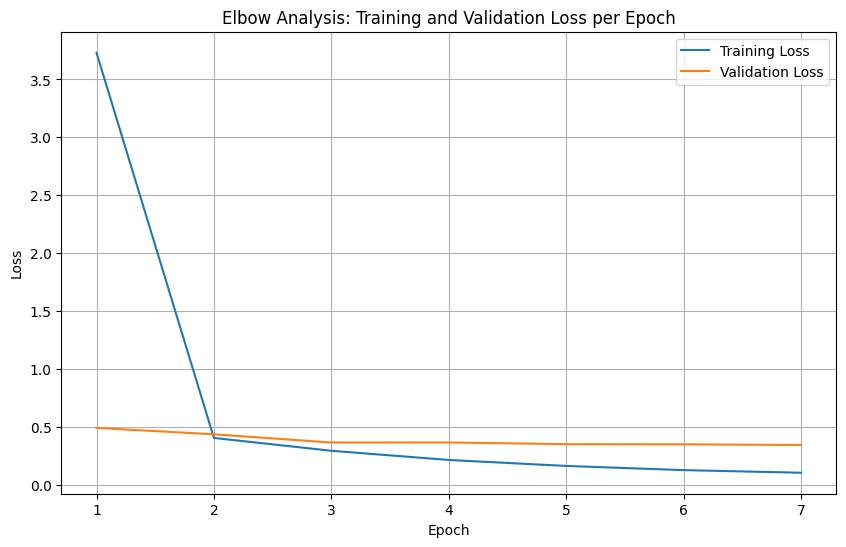

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss')
plt.title('Elbow Analysis: Training and Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.xticks(range(1, len(train_losses) + 1))
plt.show()

### Step 4: Evaluate model performance on dev set

- Define helper function `get_prd`:
  - For **dev**: get both predictions and gold labels.
  - For **pred**: only get predictions (no gold labels).
- Define `evaluate_predictions_task1`:
  - Compute Pearson Correlation Coefficient (PCC) for Valence (V) and Arousal (A).
  - Compute normalized RMSE for combined VA score.
- Run evaluation on laptop and restaurant dev sets.
- Print metrics to check how well the models perform.


In [10]:
#==== step 4 use dev data to check your model's performance ====
def get_prd(model,dataloder, type ="dev"):
    if type == "dev":
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in dataloder:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].cpu().numpy()
                outputs = model(input_ids, attention_mask).cpu().numpy()
                all_preds.append(outputs)
                all_labels.append(labels)
        preds = np.vstack(all_preds)
        lables = np.vstack(all_labels)

        pred_v = preds[:,0]
        pred_a = preds[:,1]

        gold_v = lables[:,0]
        gold_a = lables[:,1]

        return pred_v, pred_a, gold_v, gold_a

    elif type == "pred":
        all_preds = []
        with torch.no_grad():
            for batch in dataloder:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                outputs = model(input_ids, attention_mask).cpu().numpy()
                all_preds.append(outputs)
        preds = np.vstack(all_preds)

        pred_v = preds[:, 0]
        pred_a = preds[:, 1]

        return pred_v, pred_a

def evaluate_predictions_task1(pred_a, pred_v, gold_a, gold_v):
    if not (all(1 <= x <= 9 for x in pred_v) and all(1 <= x <= 9 for x in pred_a)):
        print(f"Warning: Some predicted values are out of the numerical range.")
    pcc_v = pearsonr(pred_v, gold_v)[0]
    pcc_a = pearsonr(pred_a, gold_a)[0]

    gold_va = gold_v + gold_a
    pred_va = pred_v + pred_a

    def rmse(gold_va, pred_va):
        result = [(a - b) ** 2 for a, b in zip(gold_va, pred_va)]
        return math.sqrt(sum(result)/len(gold_v))

    rmse_va = rmse(gold_va, pred_va)
    return {
        'PCC_V': pcc_v,
        'PCC_A': pcc_a,
        'RMSE_VA': rmse_va,
    }

# lap dev score
pred_v, pred_a, gold_v, gold_a = get_prd(model, dev_loader,type="dev")
eval_score = evaluate_predictions_task1(pred_a, pred_v, gold_a, gold_v)
print(f"{model_name} dev_eval: {eval_score}")

xlm-roberta-base dev_eval: {'PCC_V': 0.9052433, 'PCC_A': 0.8361374, 'RMSE_VA': 0.9595513109923356}


## Preparing files for submission


In [11]:
predict_raw ={}
train_raw={}
task = "task1"
for lang in langs:
    for domain in domains:
        
        if domain=="finance":
            specified_task = "task1"
        else:
            specified_task = "alltasks"
        # specified_task = "alltasks"
        
        train_url = f"https://raw.githubusercontent.com/DimABSA/DimABSA2026/refs/heads/main/task-dataset/track_a/{subtask}/{lang}/{lang}_{domain}_train_{specified_task}.jsonl"
        predict_url = f"https://raw.githubusercontent.com/DimABSA/DimABSA2026/refs/heads/main/task-dataset/track_a/{subtask}/{lang}/{lang}_{domain}_dev_{task}.jsonl"

        key = f"{lang}_{domain}"
        raw_train_data = load_jsonl_url(train_url)
        if raw_train_data:
            # Inject language and domain into every dictionary in the list
            for entry in raw_train_data:
                entry['language'] = lang
                entry['domain'] = domain
            train_raw[key] = raw_train_data
            print(f"Loaded Train: {key}")
        else:
            print(f"Skipped Train: {key}")
            
        raw_predict_data = load_jsonl_url(predict_url)
        if raw_predict_data:
            # Inject language and domain here too!
            for entry in raw_predict_data:
                entry['language'] = lang
                entry['domain'] = domain
            predict_raw[key] = raw_predict_data
            print(f"Loaded Predict: {key}")
        else:
            print(f"Skipped Predict: {key}")



predict_df={}
train_df={}
dev_df={}
for lang in langs:
    for domain in domains:
        try:
            train_df[lang+"_"+domain] = jsonl_to_df(train_raw[lang+"_"+domain])
            predict_df[lang+"_"+domain] = jsonl_to_df(predict_raw[lang+"_"+domain])
            train_df[lang+"_"+domain], dev_df[lang+"_"+domain] = train_test_split(train_df[lang+"_"+domain], test_size=0.1, random_state=42)
        except KeyError:
            continue



for lang in langs:
    for domain in domains:
      try:
          display(Markdown(f"### {subtask}_{lang}_{domain} train_df"))
          display(train_df[lang+"_"+domain].head())
    
          display(Markdown(f"### {subtask}_{lang}_{domain} dev_df"))
          display(dev_df[lang+"_"+domain].head())
    
          display(Markdown(f"### {subtask}_{lang}_{domain} predict_df"))
          display(predict_df[lang+"_"+domain].head())
      except:
          continue

dev_dataset={}
dev_loader={}
for lang in langs:
    for domain in domains:
      try:
        dev_dataset[lang+"_"+domain] = VADataset(dev_df[lang+"_"+domain], tokenizer)
        dev_loader[lang+"_"+domain] = DataLoader(dev_dataset[lang+"_"+domain], batch_size=64, shuffle=False)
      except KeyError:
        print("not found")


Loaded Train: eng_restaurant
Loaded Predict: eng_restaurant
Loaded Train: eng_laptop
Loaded Predict: eng_laptop
Error loading JSONL from https://raw.githubusercontent.com/DimABSA/DimABSA2026/refs/heads/main/task-dataset/track_a/subtask_1/eng/eng_finance_train_task1.jsonl: 404 Client Error: Not Found for url: https://raw.githubusercontent.com/DimABSA/DimABSA2026/refs/heads/main/task-dataset/track_a/subtask_1/eng/eng_finance_train_task1.jsonl
Skipped Train: eng_finance
Error loading JSONL from https://raw.githubusercontent.com/DimABSA/DimABSA2026/refs/heads/main/task-dataset/track_a/subtask_1/eng/eng_finance_dev_task1.jsonl: 404 Client Error: Not Found for url: https://raw.githubusercontent.com/DimABSA/DimABSA2026/refs/heads/main/task-dataset/track_a/subtask_1/eng/eng_finance_dev_task1.jsonl
Skipped Predict: eng_finance
Error loading JSONL from https://raw.githubusercontent.com/DimABSA/DimABSA2026/refs/heads/main/task-dataset/track_a/subtask_1/eng/eng_hotel_train_alltasks.jsonl: 404 Clie

### subtask_1_eng_restaurant train_df

,Aspect,ID,Text,language,domain,Valence,Arousal
481,winelist,rest16_quad_test_127,seattle ' s best winelist,eng,restaurant,8.25,8.38
2520,veal,rest16_quad_train_814,"the restaurant has a family feel , not least w...",eng,restaurant,5.67,5.33
3067,bathroom,rest16_quad_train_1157,"service ok but unfriendly , filthy bathroom .",eng,restaurant,3.33,5.83
667,crab cakes,rest16_quad_test_222,best crab cakes in town,eng,restaurant,6.88,6.50
2462,NULL,rest16_quad_train_781,they are not helpful in the least and will giv...,eng,restaurant,3.17,7.00


### subtask_1_eng_restaurant dev_df

,Aspect,ID,Text,language,domain,Valence,Arousal
172,NULL,rest16_quad_dev_118,way below average,eng,restaurant,2.67,7.00
351,pizza place,rest16_quad_test_53,mama mia – i live in the neighborhood and feel...,eng,restaurant,7.88,8.00
3132,cocktail with citrus vodka and lemon and lime ...,rest16_quad_train_1191,the have a great cocktail with citrus vodka an...,eng,restaurant,7.88,8.12
1993,place,rest16_quad_train_499,not a great place for family or general dining .,eng,restaurant,3.00,6.75
366,food,rest16_quad_test_64,"the food is great , the bartenders go that ext...",eng,restaurant,7.67,7.50


...

,Aspect,ID,Text,language,domain,Valence,Arousal
1336,每股盈餘,6491114:S006,因此，既使受到中國大陸地區殺價競爭及日圓匯率的壓力，全年淨利及每股盈餘仍保持成長。,zho,finance,5.83,5.50
1450,產品,2365112:S012,由電腦週邊跨入非電腦週邊，增加遊戲類、藍牙、Type-C等產品。,zho,finance,5.00,4.88
2478,洗車服務品質,9937111:S039,提升洗車服務品質，增加服務項目，俾增加洗車收益。,zho,finance,6.00,5.00
1791,階段性的目標,1789108:S016,去年整年，神隆常熟重新檢視及建構不同於以往的發展計畫及進行內部調動，目前亦積極排除發展過程中...,zho,finance,5.75,5.12
1475,整體供應體系管理,2330112:S022,台積公司在創新、公司治理、永續發展、投資人關係及整體供應體系管理方面，獲得富比世雜誌、財富雜...,zho,finance,5.80,5.30


### subtask_1_zho_finance predict_df

,Aspect,ID,Text,language,domain,Valence,Arousal
0,智慧城市,3481114:S057,因應智慧城市與戶外顯示需求的快速發展，推動多領域顯示應用面板的全面升級，本公司積極將Mini...,zho,finance,0,0
1,多領域顯示應用面板,3481114:S057,因應智慧城市與戶外顯示需求的快速發展，推動多領域顯示應用面板的全面升級，本公司積極將Mini...,zho,finance,0,0
2,傳統背光,3481114:S057,因應智慧城市與戶外顯示需求的快速發展，推動多領域顯示應用面板的全面升級，本公司積極將Mini...,zho,finance,0,0
3,戶外顯示需求,3481114:S057,因應智慧城市與戶外顯示需求的快速發展，推動多領域顯示應用面板的全面升級，本公司積極將Mini...,zho,finance,0,0
4,資本管理,5880108:S075,本公司108年度發展重點將以創新金融服務、發揮共體綜效、善用資源價值、優化資本管理、提高海外...,zho,finance,0,0


### subtask_1_zho_hotel train_df

not found
not found
not found


In [12]:
# lap dev score
for lang in langs:
    for domain in domains:
        try:
          pred_v, pred_a, gold_v, gold_a = get_prd(model, dev_loader[lang+"_"+domain],type="dev")
          eval_score = evaluate_predictions_task1(pred_a, pred_v, gold_a, gold_v)
          print(f"{lang}_{domain} dev_eval: {eval_score}")
        except:
          continue

eng_restaurant dev_eval: {'PCC_V': 0.98338234, 'PCC_A': 0.9471287, 'RMSE_VA': 0.5464885609303728}
eng_laptop dev_eval: {'PCC_V': 0.9895295, 'PCC_A': 0.9674988, 'RMSE_VA': 0.45361953327098054}
zho_restaurant dev_eval: {'PCC_V': 0.97461087, 'PCC_A': 0.9023161, 'RMSE_VA': 0.397664912158041}
zho_laptop dev_eval: {'PCC_V': 0.975007, 'PCC_A': 0.9106704, 'RMSE_VA': 0.42597317215624503}
zho_finance dev_eval: {'PCC_V': 0.9262216, 'PCC_A': 0.83425564, 'RMSE_VA': 0.33880971619476236}


In [13]:
#==== step 5 save & submit your predict results ====
def extract_num(s):
    m = re.search(r"(\d+)$", str(s))
    return int(m.group(1)) if m else -1

def df_to_jsonl(df, out_path):
    df_sorted = df.sort_values(by="ID", key=lambda x: x.map(extract_num))
    grouped = df_sorted.groupby("ID", sort=False)

    with open(out_path, "w", encoding="utf-8") as f:
        for gid, gdf in grouped:
            record = {
                "ID": gid,
                "Aspect_VA": []
            }
            for _, row in gdf.iterrows():
                record["Aspect_VA"].append({
                    "Aspect": row["Aspect"],
                    "VA": f"{row['Valence']:.2f}#{row['Arousal']:.2f}"
                })
            f.write(json.dumps(record, ensure_ascii=False) + "\n")
for lang in langs:
    for domain in domains:
        try: 
            pred_dataset = VADataset(predict_df[lang+"_"+domain], tokenizer)
            pred_loader = DataLoader(pred_dataset, batch_size=64, shuffle=False)
            pred_v, pred_a, = get_prd(model, pred_loader,type="pred")
            
            # Apply clipping here for consistency
            predict_df[lang+"_"+domain]["Valence"] = np.clip(pred_v, 1, 9)
            predict_df[lang+"_"+domain]["Arousal"] = np.clip(pred_a, 1, 9)
            
            df_to_jsonl(predict_df[lang+"_"+domain], f"pred_{lang}_{domain}.jsonl")
        except KeyError:
            continue


In [14]:
import os
import shutil
import zipfile
from IPython.display import FileLink, display

# Ensure your config variables exist
# subtask = "subtask_1" 
# langs = ["eng", "zho"]
# domains = ["restaurant", "laptop", "finance", "hotel"]

# 1. Create the output directory
os.makedirs(subtask, exist_ok=True)

# 2. Move the prediction files into the folder
moved_count = 0
for lang in langs:
    for domain in domains:
        fname = f"pred_{lang}_{domain}.jsonl"
        
        # Check if the file exists in the current directory
        if os.path.exists(fname):
            # Move to the subtask folder
            destination = os.path.join(subtask, fname)
            # Remove destination if it already exists (to avoid errors on re-runs)
            if os.path.exists(destination):
                os.remove(destination)
            shutil.move(fname, destination)
            moved_count += 1

print(f"✅ Moved {moved_count} files into '{subtask}/'")

# 3. Create the ZIP file
zip_filename = f"{subtask}.zip"
with zipfile.ZipFile(zip_filename, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, _, files_in_dir in os.walk(subtask):
        for file in files_in_dir:
            path = os.path.join(root, file)
            # This ensures the zip contains the folder 'subtask_1/file.jsonl'
            zf.write(path, os.path.relpath(path, "."))

print(f"📦 Created archive: {zip_filename}")

# 4. Generate Download Link (Kaggle Specific)
print("Click the link below to download your submission:")
display(FileLink(zip_filename))

✅ Moved 5 files into 'subtask_1/'
📦 Created archive: subtask_1.zip
Click the link below to download your submission:


/kaggle/working/subtask_1.zip

In [15]:
from huggingface_hub import HfApi, login
import torch
import os
import json


hf_token = os.environ["HF_TOKEN"]

# Log in programmatically to ensure permissions are active
login(token=hf_token)

# --- 2. CONFIGURATION ---
repo_id = "affan002/xlm-roberta-base-task1-engzho_aug_llama8b" 
save_directory = "hf_model_export"
os.makedirs(save_directory, exist_ok=True)

# --- 3. PREPARE MODEL ---
# Assuming 'model' is already defined in your notebook/script
if os.path.exists('best_model.pth'):
    model.load_state_dict(torch.load('best_model.pth'))
    print("Loaded best weights from best_model.pth")

model.eval() 

# --- 4. SAVE ARTIFACTS ---

# A. Save the Tokenizer
tokenizer.save_pretrained(save_directory)

# B. Save the Model Weights
torch.save(model.state_dict(), os.path.join(save_directory, "pytorch_model.bin"))

# C. Save the Configuration
try:
    # Check for config in common locations
    if hasattr(model, 'config'):
        model.config.save_pretrained(save_directory)
    elif hasattr(model, 'transformer') and hasattr(model.transformer, 'config'):
        model.transformer.config.save_pretrained(save_directory)
    elif hasattr(model, 'roberta') and hasattr(model.roberta, 'config'):
        model.roberta.config.save_pretrained(save_directory)
    else:
        print("⚠️ WARNING: Could not automatically find .config. You may need to copy config.json manually.")
except Exception as e:
    print(f"⚠️ Error saving config: {e}")

print(f"Artifacts saved to {save_directory}")

# --- 5. UPLOAD TO HUB (UPDATED) ---
# [IMPORTANT] Pass the token explicitly here to avoid 401 errors
api = HfApi(token=hf_token)

# Create repo
print(f"Creating repo: {repo_id}")
api.create_repo(repo_id=repo_id, private=False, exist_ok=True)

# Upload
print("Pushing to Hub... this may take a while for large models.")
api.upload_folder(
    folder_path=save_directory,
    repo_id=repo_id,
    repo_type="model",
    commit_message="Upload best model weights and tokenizer"
)

print(f"✅ Success! View your model here: https://huggingface.co/{repo_id}")

⚠️ WARNING: Could not automatically find .config. You may need to copy config.json manually.
Artifacts saved to hf_model_export
Creating repo: affan002/xlm-roberta-base-task1-engzho_aug_llama8b
Pushing to Hub... this may take a while for large models.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

✅ Success! View your model here: https://huggingface.co/affan002/xlm-roberta-base-task1-engzho_aug_llama8b


In [16]:
from transformers import AutoConfig

# --- REPLACEMENT FOR SECTION 4C ---

print("Generating standard config for XLM-Roberta...")

# 1. Download the default configuration for the base model
# This creates the 'config.json' object in memory
config = AutoConfig.from_pretrained("xlm-roberta-base")

# 2. Save it to your folder
config.save_pretrained(save_directory)

print(f"✅ forced creation of config.json in {save_directory}")

Generating standard config for XLM-Roberta...
✅ forced creation of config.json in hf_model_export


In [17]:
api.upload_file(
    path_or_fileobj="hf_model_export/config.json",
    path_in_repo="config.json",
    repo_id=repo_id,
    repo_type="model"
)

CommitInfo(commit_url='https://huggingface.co/affan002/xlm-roberta-base-task1-engzho_aug_llama8b/commit/e75a15e9c432b5e6a27aa1d6fd618e647e1b2886', commit_message='Upload config.json with huggingface_hub', commit_description='', oid='e75a15e9c432b5e6a27aa1d6fd618e647e1b2886', pr_url=None, repo_url=RepoUrl('https://huggingface.co/affan002/xlm-roberta-base-task1-engzho_aug_llama8b', endpoint='https://huggingface.co', repo_type='model', repo_id='affan002/xlm-roberta-base-task1-engzho_aug_llama8b'), pr_revision=None, pr_num=None)

 Results:

  eng-laptop

  bert-base-multilingual-cased dev_eval: {'PCC_V': np.float32(0.5870279), 'PCC_A': np.float32(0.48327857), 'RMSE_VA': 2.059277183976644}

  eng-resturant

  zho-laptop

  zho-resturant


### Step 5: Save and submit prediction results

- Define helper `df_to_jsonl`:
  - Sort by ID number.
  - Group rows by ID.
  - Save predictions in JSONL format (`ID`, `Aspect_VA`).
- Run the model on the predict sets (laptop & restaurant).
- Fill in predicted Valence/Arousal values.
- Export three JSONL files:




  - `pred_eng_laptop.jsonl`
  - `pred_eng_restaurant.jsonl`
  - `pred_zho_laptop.jsonl`
- These files can be uploaded as the final submission.


### File Naming Guidelines
When submitting your predictions on the Codabench task page:

Decide the target language(s) and domain(s). Each submission file corresponds to one language-domain combination.
For each language-domain combination, name the file pred_[lang_code]_[domain].jsonl, where
- [lang_code] represents a 3-letter language code, and
- [domain] represents a domain.
For example, Hausa predictions for the movie domain should be named pred_hau_movie.jsonl.
If submitting for multiple languages or domains, submit one prediction file per language-domain combination. For example, submitting for multiple languages or domains would look like this:
```plaintext
subtask_1
├── pred_eng_restaurant.jsonl
├── pred_eng_laptop.jsonl
└── pred_zho_laptop.jsonl

In [18]:
# #==== step 5 save & submit your predict results ====
# def extract_num(s):
#     m = re.search(r"(\d+)$", str(s))
#     return int(m.group(1)) if m else -1

# def df_to_jsonl(df, out_path):
#     df_sorted = df.sort_values(by="ID", key=lambda x: x.map(extract_num))
#     grouped = df_sorted.groupby("ID", sort=False)

#     with open(out_path, "w", encoding="utf-8") as f:
#         for gid, gdf in grouped:
#             record = {
#                 "ID": gid,
#                 "Aspect_VA": []
#             }
#             for _, row in gdf.iterrows():
#                 record["Aspect_VA"].append({
#                     "Aspect": row["Aspect"],
#                     "VA": f"{row['Valence']:.2f}#{row['Arousal']:.2f}"
#                 })
#             f.write(json.dumps(record, ensure_ascii=False) + "\n")

# pred_dataset = VADataset(predict_df, tokenizer)
# pred_loader = DataLoader(pred_dataset, batch_size=64, shuffle=False)
# pred_v, pred_a, = get_prd(model, pred_loader,type="pred")

# predict_df["Valence"] = np.clip(pred_v, 1, 9)
# predict_df["Arousal"] = np.clip(pred_a, 1, 9)

# df_to_jsonl(predict_df, f"pred_{lang}_{domain}.jsonl")

### Download the submit files

In [19]:
# import os
# import shutil
# import zipfile
# from google.colab import files

# # Create the folder subtask if it does not exist
# os.makedirs(subtask, exist_ok=True)
# # 
# # Move the three files into the subtask folder
# for fname in [f"pred_{lang}_{domain}.jsonl"]:
#     if os.path.exists(fname):
#         shutil.move(fname, os.path.join(subtask, fname))

# # Create a zip file named "submit.zip" containing the folder subtask
# with zipfile.ZipFile(f"{subtask}.zip", "w", zipfile.ZIP_DEFLATED) as zf:
#     for root, _, files_in_dir in os.walk(subtask):
#         for file in files_in_dir:
#             path = os.path.join(root, file)
#             # Keep folder structure inside the zip
#             zf.write(path, os.path.relpath(path, "."))

# # Download the created zip file to local machine
# files.download(f"{subtask}.zip")

In [20]:
# from here my code

In [21]:
# import torch, os
# from transformers import AutoTokenizer

# save_dir = "./transformer_va_regressor"
# os.makedirs(save_dir, exist_ok=True)

# # Save tokenizer
# tokenizer.save_pretrained(save_dir)

# # Save model backbone config (for reloading)
# model.backbone.config.save_pretrained(save_dir)

# # Save model weights
# torch.save(model.state_dict(), os.path.join(save_dir, "pytorch_model.bin"))

# print(f"✅ Model and tokenizer saved to {save_dir}")


In [22]:
# from huggingface_hub import login
# login(token=os.environ["HF_TOKEN"])

In [23]:


# from huggingface_hub import HfApi

# # ✅ Upload to Hugging Face
# repo_id = "hassanshahzad2003/bert-base-multilingual-cased-task1.2"

# api = HfApi()
# api.create_repo(repo_id=repo_id, exist_ok=True)
# api.upload_folder(
#     folder_path=save_dir,
#     repo_id=repo_id,
#     commit_message="Upload fine-tuned TransformerVARegressor"
# )

# print(f"✅ Uploaded to https://huggingface.co/{repo_id}")

### Conclusion

In this notebook, we walked through the full pipeline for **Dimensional Aspect Sentiment Regression (DimASR)**:

1. **Load data**: Import the competition JSONL files, split train/dev sets, and convert to DataFrames.  
2. **Build dataset & dataloaders**: Define a custom `VADataset` to tokenize text and prepare `[Valence, Arousal]` labels.  
3. **Train & evaluate**: Train BERT-based regressors and check model performance on the dev sets using PCC and RMSE metrics.  
4. **Predict & submit**: Run the trained models on the prediction sets, generate VA scores, and save results as JSONL for submission.  

This pipeline ensures that your model is trained, validated, and ready for competition submission. You can further improve results by tuning hyperparameters, trying different pretrained models, or applying data augmentation strategies.


In [24]:
model.eval()

TransformerVARegressor(
  (backbone): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): XLMRobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=Tr

In [25]:
# # (These variables are all defined from re-running the cells above)
# # model_name = "xlm-roberta-large"
# # device = ...
# # tokenizer = ...
# # BEST_MODEL_PATH = "/kaggle/working/best_sighan_model.bin"

# print(f"--- Loading best model from {BEST_MODEL_PATH} ---")

# # 1. Re-initialize your model structure "shell"
# model_to_eval = TransformerVARegressor(model_name=model_name).to(device)

# # 2. Resize embeddings (must match the saved model)
# model_to_eval.backbone.resize_token_embeddings(len(tokenizer))
# print("Model embeddings resized.")

# # 3. Load the saved weights into the model "shell"
# model_to_eval.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))

# # 4. Set model to evaluation mode (disables dropout)
# model_to_eval.eval()

# print("Best model loaded and ready for evaluation.")

In [26]:
# #task config
# subtask = "subtask_1"#don't change
# task = "task1"#don't change
# langs = ["eng","zho","jpn","rus","tat","ukr"] #chang the language you want to test
# domains = ["restaurant","laptop","finance","hotel"] #change what domain you want to test
# predict_raw ={}
# train_raw={}

# for lang in langs:
#     for domain in domains:
        
#         train_url = f"https://raw.githubusercontent.com/DimABSA/DimABSA2026/refs/heads/main/task-dataset/track_a/{subtask}/{lang}/{lang}_{domain}_train_alltasks.jsonl"
#         predict_url = f"https://raw.githubusercontent.com/DimABSA/DimABSA2026/refs/heads/main/task-dataset/track_a/{subtask}/{lang}/{lang}_{domain}_dev_{task}.jsonl"
#         try:
#             train_data = load_jsonl_url(train_url)
#             predict_data = load_jsonl_url(predict_url)
#             key = lang+"_"+domain
#             if train_data:
#                 train_raw[key] = train_data
#                 for r in train_raw[key]:
#                         r["language"] = lang
#                         r["domain"] = domain
#             if predict_data:
#                 predict_raw[key] = predict_data
#                 for r in predict_raw[lang+"_"+domain]:
#                     r["language"] = lang
#                     r["domain"] = domain
#         except:
#             continue

In [27]:
# #==== step 1 load the data ====
# # you can change the env for your task.
# # train data should have the VA labels, predit data without VA labels

# def jsonl_to_df(data):
#     print(data[0])
#     if 'Quadruplet' in data[0]:
#         df = pd.json_normalize(data, 'Quadruplet', ['ID', 'Text', 'language', 'domain'])
#         df[['Valence', 'Arousal']] = df['VA'].str.split('#', expand=True).astype(float)
#         df = df.drop(columns=['VA', 'Category', 'Opinion'])  # drop unnecessary columns
#         df = df.drop_duplicates(subset=['ID', 'Aspect'], keep='first')  # remove duplicate ID+Aspect

#     elif 'Triplet' in data[0]:
#         df = pd.json_normalize(data, 'Triplet', ['ID', 'Text', 'language', 'domain'])
#         df[['Valence', 'Arousal']] = df['VA'].str.split('#', expand=True).astype(float)
#         df = df.drop(columns=['VA', 'Opinion'])  # drop unnecessary columns
#         df = df.drop_duplicates(subset=['ID', 'Aspect'], keep='first')  # remove duplicate ID+Aspect

#     elif 'Aspect' in data[0]:
#         df = pd.json_normalize(data, 'Aspect', ['ID', 'Text', 'language', 'domain'])
#         df = df.rename(columns={df.columns[0]: "Aspect"})  # rename to Aspect
#         df['Valence'] = 0  # default value
#         df['Arousal'] = 0  # default value

#     else:
#         raise ValueError("Invalid format: must include 'Quadruplet' or 'Triplet' or 'Aspect'")

#     return df

# predict_df={}
# train_df={}
# dev_df={}
# for lang in langs:
#     for domain in domains:
#         try:
#             train_df[lang+"_"+domain] = jsonl_to_df(train_raw[lang+"_"+domain])
#             predict_df[lang+"_"+domain] = jsonl_to_df(predict_raw[lang+"_"+domain])
#             train_df[lang+"_"+domain], dev_df[lang+"_"+domain] = train_test_split(train_df[lang+"_"+domain], test_size=0.1, random_state=42)
#         except KeyError:
#             continue



In [28]:
# for lang in langs:
#     for domain in domains:
#         try:  
#             display(Markdown(f"### {subtask}_{lang}_{domain} train_df"))
#             display(train_df[lang+"_"+domain].head())
            
#             display(Markdown(f"### {subtask}_{lang}_{domain} dev_df"))
#             display(dev_df[lang+"_"+domain].head())
            
#             display(Markdown(f"### {subtask}_{lang}_{domain} predict_df"))
#             display(predict_df[lang+"_"+domain].head())
#         except KeyError:
#             continue

In [29]:

# MAX_LEN = 128

# BATCH_SIZE = 16
# #==== Dataset ====
# class VADataset(Dataset):
#     '''
#     A PyTorch Dataset for Valence–Arousal regression.

#     - Combines aspect and text into a single input (e.g., "keyboard: The keyboard is good").
#     - Tokenizes the input using a HuggingFace tokenizer.
#     - Returns:
#         * input_ids: token IDs, shape [max_len]
#         * attention_mask: mask, shape [max_len]
#         * labels: [Valence, Arousal], shape [2], float tensor

#     Args:
#         dataframe (pd.DataFrame): must contain "Text", "Aspect", "Valence", "Arousal".
#         tokenizer: HuggingFace tokenizer.
#         max_len (int): max sequence length.
#     '''
#     def __init__(self, dataframe, tokenizer, max_len):
#         self.sentences = dataframe["Text"].tolist()
#         self.aspects = dataframe["Aspect"].tolist()
#         self.labels = dataframe[["Valence", "Arousal"]].values.astype(float)
#         self.languages = dataframe["language"].tolist()
#         self.domains = dataframe["domain"].tolist()
#         self.tokenizer = tokenizer
#         self.max_len = max_len

#     def __len__(self):
#         return len(self.sentences)

#     def __getitem__(self, idx):
#         # lang = self.languages[idx].upper()
#         domain = self.domains[idx].upper()
#         text = f"[{domain}] {self.aspects[idx]}: {self.sentences[idx]}"

#         encoded = self.tokenizer(
#             text,
#             truncation=True,
#             padding="max_length",
#             max_length=self.max_len,
#             return_tensors="pt"
#         )

#         return {
#             "input_ids": encoded["input_ids"].squeeze(0),
#             "attention_mask": encoded["attention_mask"].squeeze(0),
#             "labels": torch.tensor(self.labels[idx], dtype=torch.float)
#         }


# dev_dataset={}
# dev_loader={}
# for lang in langs:
#     for domain in domains:
#       try:
#         dev_dataset[lang+"_"+domain] = VADataset(dev_df[lang+"_"+domain], tokenizer, max_len=MAX_LEN)
#         dev_loader[lang+"_"+domain] = DataLoader(dev_dataset[lang+"_"+domain], batch_size=BATCH_SIZE, shuffle=False)
#       except KeyError:
#         continue

## start running for evaluation


In [30]:
# # lap dev score
# for lang in langs:
#     for domain in domains:
#       try:
#         pred_v, pred_a, gold_v, gold_a = get_prd(model, dev_loader[lang+"_"+domain],type="dev")
#         eval_score = evaluate_predictions_task1(pred_a, pred_v, gold_a, gold_v)
#         print(f"{lang}_{domain} dev_eval: {eval_score}")
#       except KeyError:
#         continue

In [31]:
# import os 

# #==== step 5 save & submit your predict results ====
# def extract_num(s):
#     m = re.search(r"(\d+)$", str(s))
#     return int(m.group(1)) if m else -1

# def df_to_jsonl(df, out_path):
#     df_sorted = df.sort_values(by="ID", key=lambda x: x.map(extract_num))
#     grouped = df_sorted.groupby("ID", sort=False)

#     with open(out_path, "w", encoding="utf-8") as f:
#         for gid, gdf in grouped:
#             record = {
#                 "ID": gid,
#                 "Aspect_VA": []
#             }
#             for _, row in gdf.iterrows():
#                 record["Aspect_VA"].append({
#                     "Aspect": row["Aspect"],
#                     "VA": f"{row['Valence']:.2f}#{row['Arousal']:.2f}"
#                 })
#             f.write(json.dumps(record, ensure_ascii=False) + "\n")

# # --- 2. Create the submission folder ---
# os.makedirs(subtask, exist_ok=True)
# print(f"Saving files to './{subtask}/' folder...")

# for lang in langs:
#     for domain in domains:
#       key = f"{lang}_{domain}"
#       try:
#         pred_dataset = VADataset(predict_df[key], tokenizer, max_len=MAX_LEN)
#         pred_loader = DataLoader(pred_dataset, batch_size=BATCH_SIZE, shuffle=False)
#         pred_v, pred_a, = get_prd(model, pred_loader,type="pred")

#         clipped_v = np.clip(pred_v, 1, 9)
#         clipped_a = np.clip(pred_a, 1, 9)

#         predict_df[key]["Valence"] = clipped_v
#         predict_df[key]["Arousal"] = clipped_a

#         df_to_jsonl(predict_df[key], f"pred_{lang}_{domain}.jsonl")
#       except KeyError:
#         print(f"Skipping {key}: No prediction data found.")
#         continue

In [32]:
# import os
# import zipfile
# from IPython.display import FileLink # <-- KAGGLE'S download command

# # (These variables are defined in your previous cells)
# # subtask = "subtask_1"
# # langs = [...]
# # domains = [...]

# print(f"--- ZIPPING SUBMISSION FOLDER: '{subtask}' ---")

# # --- 1. Define the zip file name and path ---
# # We save it in the /kaggle/working/ directory, which is persistent
# zip_filename = f"{subtask}_submission.zip"
# zip_path = f"/kaggle/working/{zip_filename}" 

# # --- 2. Create the zip file ---
# # This code is correct. It walks the 'subtask_1' folder (where your
# # previous cell saved all the .jsonl files) and zips its contents.
# try:
#     with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
#         # Walk the 'subtask' folder
#         for root, _, files_in_dir in os.walk(subtask):
#             for file in files_in_dir:
#                 # Get the full path of the file to be zipped
#                 path_to_file = os.path.join(root, file)
                
#                 # This creates the correct internal structure
#                 # e.g., "subtask_1/pred_eng_restaurant.jsonl"
#                 archive_path = os.path.relpath(path_to_file, ".")
                
#                 print(f"Adding: {archive_path}")
#                 zf.write(path_to_file, archive_path)

#     print(f"✅ Zip file created successfully at {zip_path}")

#     # --- 3. Create a download link for Kaggle ---
#     print("\n--- Click the link below to download your submission file ---")
#     display(FileLink(zip_path))

# except FileNotFoundError:
#     print(f"ERROR: The folder '{subtask}' does not exist or is empty.")
#     print("Please go back and run the 'Step 5' (Prediction) cell to generate your .jsonl files.")
# except Exception as e:
#     print(f"An error occurred during zipping: {e}")